# Analityka anomalii w Ataku DDoS


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score

Zbiór: https://www.kaggle.com/datasets/aymenabb/ddos-evaluation-dataset-cic-ddos2019
DDoS Evaluation Dataset (CIC-DDoS2019)

# Część: Bootstrapowy przedział ufności i wykrywanie ataku DDoS

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# usunięcie spacji w nazwach kolumn 
df.columns = df.columns.str.strip()

# LOSOWA PRÓBKA 
#df_sample = df.sample(n=1000, random_state=42)
df_sample = df.iloc[:2000]

# wybór kolumny + czyszczenie
data = df_sample["Flow Packets/s"]\
    .replace([np.inf, -np.inf], np.nan)\
    .dropna()\
    .values

In [2]:
print(df.columns)

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

In [3]:
df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Funkcja bootstrap

In [ ]:
def bootstrap_ci(x, stat_func=np.mean, n_bootstrap=5000, alpha=0.05, random_state=0):
    x = np.asarray(x)
    n = len(x)
    rng = np.random.default_rng(random_state)
    stats = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        sample = x[idx]
        stats[i] = stat_func(sample)

    lower = np.quantile(stats, alpha / 2)
    upper = np.quantile(stats, 1 - alpha / 2)

    return lower, upper, stats

# Eksperyment z alpha

In [4]:
alphas = [0.1, 0.01, 0.001]

for alpha in alphas:
    _, upper, _ = bootstrap_ci(data, alpha=alpha)

    anomalies = data[data > upper]

    print(f"\nALPHA = {alpha}")
    print(f"Górna granica CI: {upper:.2f}")
    print(f"Liczba anomalii: {len(anomalies)}")


ALPHA = 0.1
Górna granica CI: 60944.78
Liczba anomalii: 128

ALPHA = 0.01
Górna granica CI: 66636.83
Liczba anomalii: 127

ALPHA = 0.001
Górna granica CI: 72311.84
Liczba anomalii: 122


Zmniejszenie wartości alpha powodowało rozszerzenie przedziałów ufności, co skutkowało mniejszą liczbą wykrytych anomalii. Większe alpha zwiększało czułość metody, ale prowadziło do większej liczby fałszywych alarmów.

# Inna statystyka niż średnia

In [5]:
def p90(x):
    return np.percentile(x, 90)

stats = {
    "mean": np.mean,
    "median": np.median,
    "p90": p90
}

for name, func in stats.items():
    _, upper, _ = bootstrap_ci(data, stat_func=func)

    anomalies = data[data > upper]

    print(f"\nStatystyka: {name}")
    print(f"Próg anomalii: {upper:.2f}")
    print(f"Liczba anomalii: {len(anomalies)}")


Statystyka: mean
Próg anomalii: 62857.77
Liczba anomalii: 127

Statystyka: median
Próg anomalii: 169.54
Liczba anomalii: 954

Statystyka: p90
Próg anomalii: 35714.29
Liczba anomalii: 173


Porównanie statystyk w metodzie bootstrap pokazuje istotny wpływ na próg anomalii i liczbę wykrytych zdarzeń. Średnia, jako statystyka wrażliwa na wartości odstające, prowadzi do najwyższego progu, co skutkuje mniejszą liczbą wykrytych anomalii. Mediana jest odporna na outliery, dlatego daje niższy próg i wykrywa więcej anomalii, zwiększając czułość detekcji. Z kolei 90. percentyl stanowi rozwiązanie pośrednie, oferując kompromis między stabilnością a zdolnością wykrywania odchyleń. W praktyce mediana i percentyle są bardziej efektywne w detekcji ataków DDoS niż średnia.

# Wykrywanie anomalii na całym sygnale, nie tylko na ddos_rps

Liczba anomalii: 127


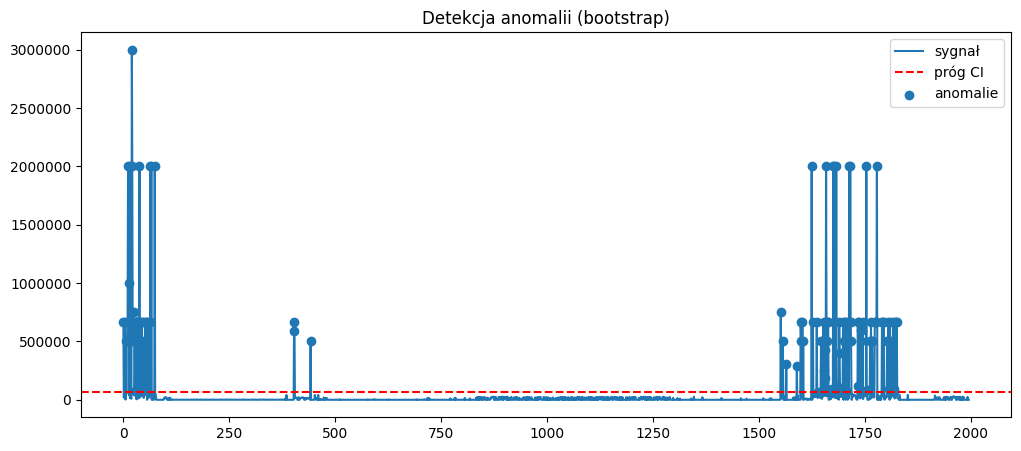

In [17]:
import matplotlib.pyplot as plt

_, upper, _ = bootstrap_ci(data)

anomaly_indices = []
anomaly_values = []

for i, r in enumerate(data):
    if r > upper:
        anomaly_indices.append(i)
        anomaly_values.append(r)

print("Liczba anomalii:", len(anomaly_indices))

plt.figure(figsize=(12,5))
plt.plot(data, label="sygnał")
plt.axhline(upper, color="red", linestyle="--", label="próg CI")
plt.ticklabel_format(style='plain', axis='y')
plt.scatter(anomaly_indices, anomaly_values, label="anomalie")

plt.legend()
plt.title("Detekcja anomalii (bootstrap)")
plt.show()

W przypadku globalnego progu bootstrap (pierwszy wykres) próg jest stały i stosunkowo niski względem wartości sygnału. W efekcie metoda oznacza jako anomalie praktycznie wszystkie większe skokim. W metodzie rolling window (drugi wykres) próg dostosowuje się do lokalnych wartości sygnału. W momentach wystąpienia dużych pików próg rośnie, a następnie spada, gdy sygnał wraca do normalnego poziomu. Dzięki temu metoda lepiej odwzorowuje zmienność danych. Jednak w spokojnych fragmentach sygnału metoda może również wykrywać zbyt dużo anomalii. Wynika to z tego, że próg wyznaczany jest na podstawie bardzo małych wartości, przez co nawet niewielkie odchylenia są traktowane jako anomalie. Jednym z rozwiązań jest zastosowanie bardziej odpornych statystyk, takich jak percentyle zamiast średniej, co pozwala podnieść próg i ograniczyć wpływ drobnych fluktuacji. Inną możliwością jest zwiększenie rozmiaru okna czasowego, co stabilizuje estymację i zmniejsza wrażliwość na lokalne wahania. Można także rozważyć wprowadzenie dodatkowych kryteriów decyzyjnych, takich jak minimalny poziom sygna



# Okno czasowe zamiast globalnego progu

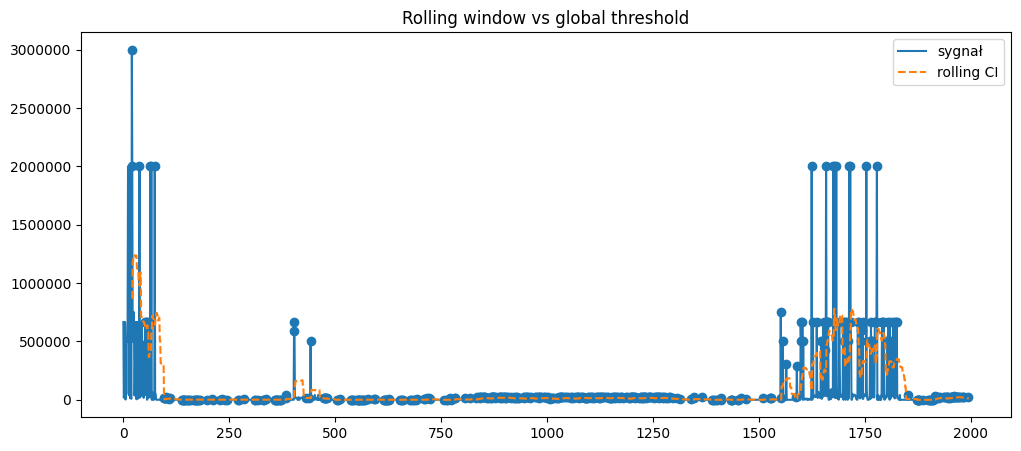

In [ ]:
window_size = 20
step = 2  # co ile punktów liczymy bootstrap

rolling_upper = np.full(len(data), np.nan)

for i in range(window_size, len(data), step):
    window = data[i-window_size:i]
    _, upper, _ = bootstrap_ci(window)

    # wypełniamy kilka punktów tym samym progiem
    rolling_upper[i:i+step] = upper

anomalies_rw = data > rolling_upper

plt.figure(figsize=(12,5))
plt.plot(data, label="sygnał")
plt.plot(rolling_upper, linestyle="--", label="rolling CI")
plt.ticklabel_format(style='plain', axis='y')
plt.scatter(np.where(anomalies_rw)[0], data[anomalies_rw])

plt.legend()
plt.title("Rolling window vs global threshold")
plt.show()

Globalny próg jest stały i bardzo niski, dlatego oznacza jako anomalie większość większych wartości, szczególnie na początku sygnału. Prowadzi to do dużej liczby wykryć, ale także wielu fałszywych alarmów.

Rolling window dopasowuje próg do lokalnych danych, na początku jest wysoki (bo widzi duże piki), a potem spada wraz z normalnym ruchem. Dzięki temu wykrywa głównie rzeczywiste skoki, a nie wszystkie odchylenia.

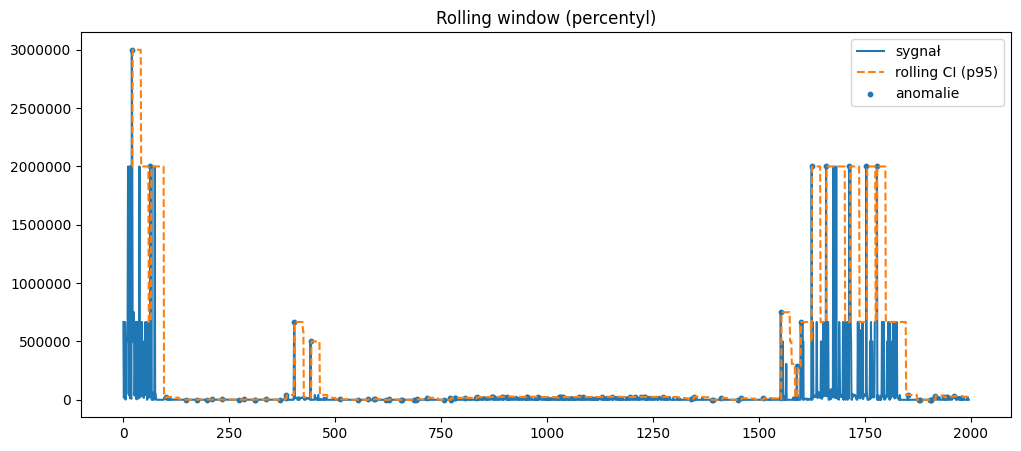

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# percentyl
def p95(x):
    return np.percentile(x, 95)

window_size = 20
step = 2

rolling_upper = np.full(len(data), np.nan)
rolling_upper_min = np.full(len(data), np.nan)

# rolling window 
for i in range(window_size, len(data), step):
    window = data[i-window_size:i]
    
    # bootstrap + percentyl
    _, upper, _ = bootstrap_ci(window, stat_func=p95, n_bootstrap=1000)
    
    rolling_upper[i:i+step] = upper


# anomalie 
idx_rw = np.where(data > rolling_upper)[0]

plt.figure(figsize=(12,5))
plt.plot(data, label="sygnał")
plt.plot(rolling_upper, linestyle="--", label="rolling CI (p95)")
plt.scatter(idx_rw, data[idx_rw], s=10, label="anomalie")

plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.title("Rolling window (percentyl)")
plt.show()




Zastosowanie percentyla zamiast średniej w metodzie rolling window pozwala na wyznaczenie bardziej restrykcyjnego i odpornego progu anomalii. Dzięki temu eliminowane są drobne fluktuacje sygnału, a wykrywane są głównie istotne odchylenia odpowiadające rzeczywistym epizodom zwiększonego ruchu.

# Eksperyment z parametrami ruchu


In [ ]:
rng = np.random.default_rng(0)

# zmienione parametry
normal = rng.normal(loc=800, scale=100, size=500) # mniejsza średnia i odchylenie
attack = rng.uniform(1500, 3000, size=50) # większy zakres ataku

combined = np.concatenate([normal, attack])

_, upper, _ = bootstrap_ci(normal)

anomalies = combined[combined > upper]

print("Nowy próg:", upper)
print("Wykryte anomalie:", len(anomalies))

Nowy próg: 805.8709552108467
Wykryte anomalie: 280


W eksperymencie wykorzystuję dane syntetyczne, generowane za pomocą generatora liczb losowych. Wcześniej ruch normalny był symulowany przy użyciu rozkładu normalnego o parametrach loc=500 i scale=30, co odpowiadało typowemu ruchowi na poziomie około 500 zapytań na sekundę (dla 360 obserwacji, czyli 6 minut pomiaru co sekundę). Wartości ataku były natomiast zdefiniowane ręcznie jako: [3000, 4500, 7200, 8000, 6000, 5500, 4000, 3500], co oznaczało bardzo wyraźne anomalie znacznie przekraczające normalny ruch. W kolejnej części eksperymentu zmieniono parametry ruchu (np. loc=800, scale=100) oraz obniżono zakres wartości ataku, aby zmniejszyć różnicę między ruchem normalnym a anomalią i sprawdzić skuteczność metody w trudniejszych warunkach. Dla tych ustawień wyznaczony nowy próg wyniósł 805.8709552108467, a liczba wykrytych anomalii to 280, co pokazuje, że metoda nadal identyfikuje dużą liczbę podejrzanych obserwacji, choć granica między ruchem normalnym a anomalią jest mniej wyraźna.

# Część: Isolation Forest (jednowymiarowe RPS)

# Różne wartości contamination 

In [3]:
from sklearn.ensemble import IsolationForest

rps = df_sample["Flow Packets/s"].replace([np.inf, -np.inf], np.nan).dropna()

X = rps.values.reshape(-1, 1)
contamination_values = [0.01, 0.05, 0.1, 0.2]

results = {}

for c in contamination_values:
    model = IsolationForest(contamination=c, random_state=0)
    labels = model.fit_predict(X)
    
    n_anomalies = np.sum(labels == -1)
    results[c] = n_anomalies
    
    print(f"contamination={c}: liczba anomalii = {n_anomalies}")

contamination=0.01: liczba anomalii = 20
contamination=0.05: liczba anomalii = 78
contamination=0.1: liczba anomalii = 199
contamination=0.2: liczba anomalii = 399


| contamination | anomalie             |
| ------------- | -------------------- |
| 0.01          | mało (tylko skrajne) |
| 0.05          | sensowny kompromis   |
| 0.1           | więcej fałszywych    |
| 0.2           | dużo overfittingu    |


# Uczenie tylko na ruchu normalnym

In [14]:
print("Unique labels:", df_sample["Label"].unique())
print("Counts:\n", df_sample["Label"].value_counts())

Unique labels: <ArrowStringArray>
['BENIGN']
Length: 1, dtype: str
Counts:
 Label
BENIGN    2000
Name: count, dtype: int64


In [10]:
threshold = np.percentile(rps, 95)

normal_data = rps[rps <= threshold].values.reshape(-1, 1) #wartość, poniżej której jest 95% danych, usuwa największe 5% wartości (potencjalne anomalie)

# trening tylko na normalnych
model_norm = IsolationForest(contamination=0.05, random_state=0)
model_norm.fit(normal_data)

labels_norm = model_norm.predict(X)

print("Anomalie (uczenie tylko na normalnych):", np.sum(labels_norm == -1))

Anomalie (uczenie tylko na normalnych): 173


Dla modelu trenowanego na całych danych liczba anomalii rośnie razem z parametrem contamination:

0.01 → 20 anomalii (tylko skrajne przypadki)

0.05 → 78

0.1 → 199

0.2 → 399 (dużo, także błędne)

Model zkałada, ile % danych ma być anomalią.


W przypadku uczenia wyłącznie na danych normalnych liczba wykrytych anomalii wyniosła 173. Wynik ten jest zbliżony do modelu z contamination = 0.1, jednak podejście to nie narzuca z góry liczby anomalii, lecz opiera się na rzeczywistym odchyleniu od wzorca normalnego ruchu.

# Wykres z anomaliami

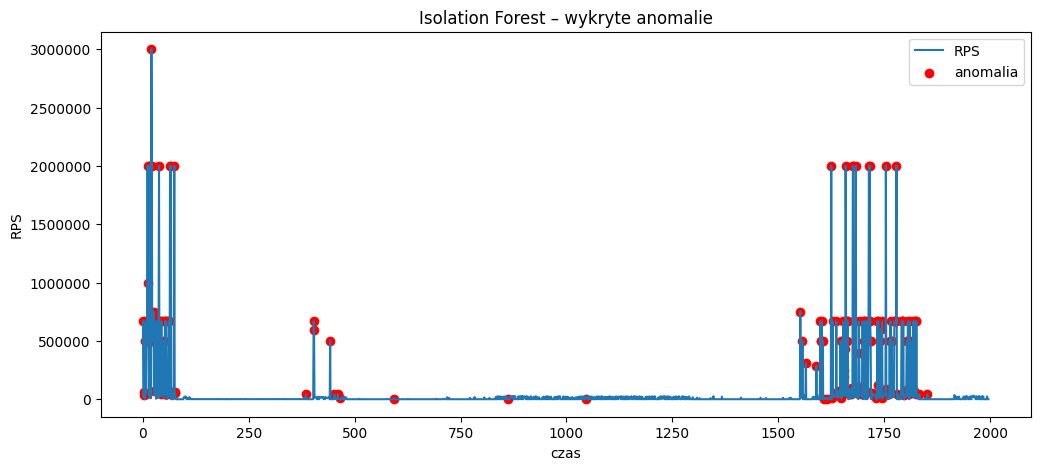

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(rps.values, label="RPS")
anomaly_idx = np.where(labels_norm == -1)[0]

plt.scatter(anomaly_idx, rps.iloc[anomaly_idx], color='red', label="anomalia")

plt.title("Isolation Forest – wykryte anomalie")
plt.xlabel("czas")
plt.ylabel("RPS")
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()

# Odczyt score’ów decyzji

In [14]:
scores = model_norm.decision_function(X)

# początek (atak)
print("Score początku:")
print(scores[:50])

Score początku:
[-0.2084709   0.12304021 -0.00202308 -0.10837141 -0.2084709   0.03412399
 -0.2084709  -0.06055014 -0.2084709  -0.2084709  -0.2084709  -0.2084709
 -0.2084709  -0.2084709   0.00312955 -0.2084709   0.0700886  -0.2084709
  0.10814037  0.00683658 -0.2084709  -0.2084709  -0.2084709  -0.2084709
 -0.2084709  -0.2084709   0.00312955 -0.12229389 -0.2084709  -0.2084709
 -0.2084709   0.01101678 -0.2084709  -0.2084709  -0.2084709   0.04688644
 -0.2084709  -0.2084709  -0.2084709   0.11947572  0.02126247  0.02061744
 -0.0182051  -0.2084709  -0.2084709  -0.1722567   0.00869628 -0.169668
  0.10764601 -0.2084709 ]


Na początku sygnału wartości decision score są w większości ujemne (np. -0.20, -0.17, -0.10), co oznacza, że model klasyfikuje te obserwacje jako anomalie.

Pojedyncze wartości dodatnie lub bliskie zeru mogą oznaczać mniej wyraźne odchylenia, ale dominują wartości ujemne.

Wniosek: model poprawnie wykrywa, że początkowy fragment danych odpowiada atakowi i ma charakter anormalny.

# Parametry strukturalne modelu

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

configs = [
    {"n_estimators": 50, "max_samples": 0.5},
    {"n_estimators": 100, "max_samples": 1.0},
    {"n_estimators": 200, "max_samples": 1.0},
]

results = {}

# apis wyników
for i, cfg in enumerate(configs):
    model = IsolationForest(
        contamination=0.05,
        n_estimators=cfg["n_estimators"],
        max_samples=cfg["max_samples"],
        random_state=42
    )
    
    labels = model.fit_predict(X)
    anomalies = np.where(labels == -1)[0]
    
    results[i] = set(anomalies)
    
    print(f"\nConfig: {cfg}")
    print("Liczba anomalii:", len(anomalies))
    print("Pierwsze indeksy:", anomalies[:10])

# porównanie
set_50 = results[0]
set_100 = results[1]
set_200 = results[2]

print("\n=== PORÓWNANIE ===")

print("50 vs 100:", len(set_50 & set_100))
print("100 vs 200:", len(set_100 & set_200))
print("50 vs 200:", len(set_50 & set_200))

print("Wspólne dla wszystkich:", len(set_50 & set_100 & set_200))

print("\n=== PROCENT POKRYCIA ===")

print("50 vs 100:", len(set_50 & set_100) / len(set_100))
print("100 vs 200:", len(set_100 & set_200) / len(set_200))
print("50 vs 200:", len(set_50 & set_200) / len(set_200))


Config: {'n_estimators': 50, 'max_samples': 0.5}
Liczba anomalii: 81
Pierwsze indeksy: [ 3  6  8  9 11 12 13 15 17 20]

Config: {'n_estimators': 100, 'max_samples': 1.0}
Liczba anomalii: 89
Pierwsze indeksy: [ 3  6  7  8  9 11 12 13 15 17]

Config: {'n_estimators': 200, 'max_samples': 1.0}
Liczba anomalii: 87
Pierwsze indeksy: [ 3  6  7  8  9 11 12 13 15 17]

=== PORÓWNANIE ===
50 vs 100: 81
100 vs 200: 87
50 vs 200: 81
Wspólne dla wszystkich: 81

=== PROCENT POKRYCIA ===
50 vs 100: 0.9101123595505618
100 vs 200: 1.0
50 vs 200: 0.9310344827586207


Większość wykrytych anomalii pokrywa się pomiędzy konfiguracjami modelu.

Wszystkie 81 anomalii z pierwszej konfiguracji występują również w pozostałych

Pokrycie między modelami wynosi ok. 91–100%

Wniosek:
Model jest stabilny — zmiana parametrów (liczba drzew, liczba próbek) ma niewielki wpływ na wyniki i dodaje tylko kilka dodatkowych anomalii.

# Część: Local Outlier Factor (LOF)

# Eksperyment z liczbą sąsiadów

In [14]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

neighbors_list = [5, 10, 20, 50]
lof_results = {}

for n in neighbors_list:
    lof = LocalOutlierFactor(n_neighbors=n, contamination=0.05)
    labels_lof = lof.fit_predict(X)
    
    anomalies = np.where(labels_lof == -1)[0]
    
    # zapisujemy wszystko
    lof_results[n] = {
        "labels": labels_lof,
        "anomalies": set(anomalies)
    }
    
    print(f"\nn_neighbors={n}")
    print("Liczba anomalii:", len(anomalies))
    print("Pierwsze indeksy:", anomalies[:20])


n_neighbors=5
Liczba anomalii: 100
Pierwsze indeksy: [  5  13  20  23  25  63  79  80  89 147 152 153 179 193 198 212 214 265
 323 324]

n_neighbors=10
Liczba anomalii: 100
Pierwsze indeksy: [  5   7  13  20  23  25  72 131 147 152 171 179 185 193 212 224 260 265
 298 323]

n_neighbors=20
Liczba anomalii: 100
Pierwsze indeksy: [  3   7  11  13  15  17  20  21  23  25  38  60  64  66  69  72  74  75
  76 147]

n_neighbors=50
Liczba anomalii: 100
Pierwsze indeksy: [ 5  6  8  9 11 12 13 15 17 20 21 22 23 24 25 28 38 45 47 49]


C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Pyth

Dla wszystkich wartości n_neighbors liczba wykrytych anomalii wynosi 100, co wynika z ustawionego parametru contamination = 0.05 (model zawsze oznacza ~5% danych jako anomalie).

Zmiana liczby sąsiadów wpływa jednak na konkretne indeksy anomalii:

dla małych wartości (5, 10) model jest bardziej lokalny → wykrywa inne punkty

dla większych (20, 50) wyniki są bardziej stabilne i zbliżone do siebie

# Porównanie indeksów IF vs LOF

In [22]:
iso = IsolationForest(contamination=0.05, random_state=42)
labels_iso = iso.fit_predict(X)
# zbiory anomalii
set_if = set(np.where(labels_iso == -1)[0])
set_lof = set(np.where(labels_lof == -1)[0])

# część wspólna (ensemble)
ensemble = set_if & set_lof

print("IF:", len(set_if))
print("LOF:", len(set_lof))
print("Ensemble (wspólne):", len(ensemble))

IF: 78
LOF: 100
Ensemble (wspólne): 64


Model Isolation Forest wykrył 78 anomalii, a LOF 100, natomiast część wspólna (ensemble) wynosi 64.

Oznacza to, że:

część anomalii wykrytych tylko przez jedną metodę może być fałszywymi alarmami

wybierając tylko wspólne wyniki (64), otrzymujemy bardziej wiarygodny zbiór anomalii

# Wizualizacja anomalii LOF na wykresie

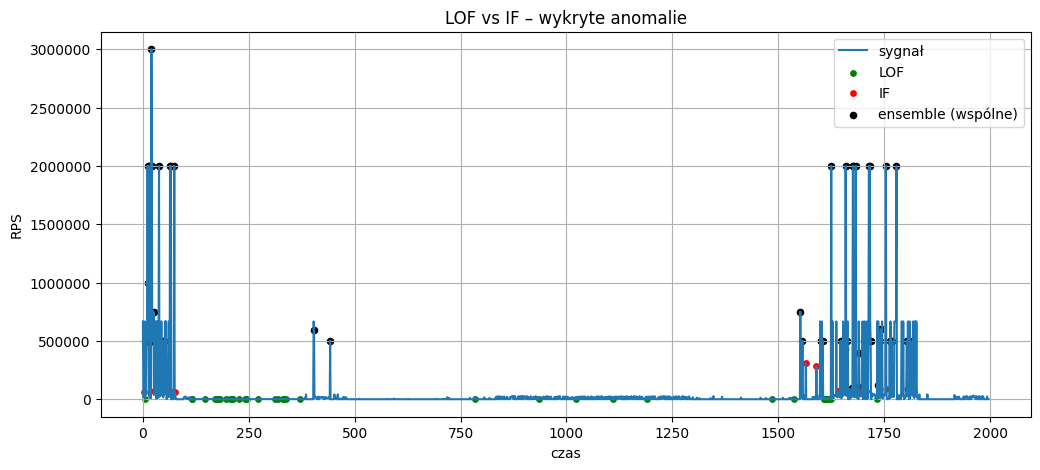

In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,5))

plt.plot(rps.values, label="sygnał")

# indeksy
idx_lof = set(np.where(labels_lof == -1)[0])
idx_if = set(np.where(labels_iso == -1)[0])

# część wspólna (ensemble)
idx_common = list(idx_lof & idx_if)

# tylko LOF
idx_lof_only = list(idx_lof - idx_if)

# tylko IF
idx_if_only = list(idx_if - idx_lof)

# rysowanie
plt.scatter(idx_lof_only, rps.iloc[idx_lof_only],
            color='green', s=15, label="LOF")

plt.scatter(idx_if_only, rps.iloc[idx_if_only],
            color='red', s=15, label="IF")

plt.scatter(idx_common, rps.iloc[idx_common],
            color='black', s=20, label="ensemble (wspólne)")

plt.grid(True)
plt.title("LOF vs IF – wykryte anomalie")
plt.xlabel("czas")
plt.ylabel("RPS")
plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.show()

# LOF z trybem novelty=True (jeśli znana wersja sklearn)

In [ ]:
# tylko dane normalne (jak wcześniej)
lof_novel = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

lof_novel.fit(normal_data)

labels_lof_novel = lof_novel.predict(X)

anomalies_lof_novel = np.where(labels_lof_novel == -1)[0]

# LOF standard
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X)


C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [47]:
set_lof = set(np.where(labels_lof == -1)[0])
set_lof_novel = set(np.where(labels_lof_novel == -1)[0])

common = set_lof & set_lof_novel
only_lof = set_lof - set_lof_novel
only_novel = set_lof_novel - set_lof

print("LOF:", len(set_lof))
print("LOF novelty:", len(set_lof_novel))
print("Wspólne:", len(common))
print("Tylko LOF:", len(only_lof))
print("Tylko novelty:", len(only_novel))

LOF: 100
LOF novelty: 157
Wspólne: 100
Tylko LOF: 0
Tylko novelty: 57


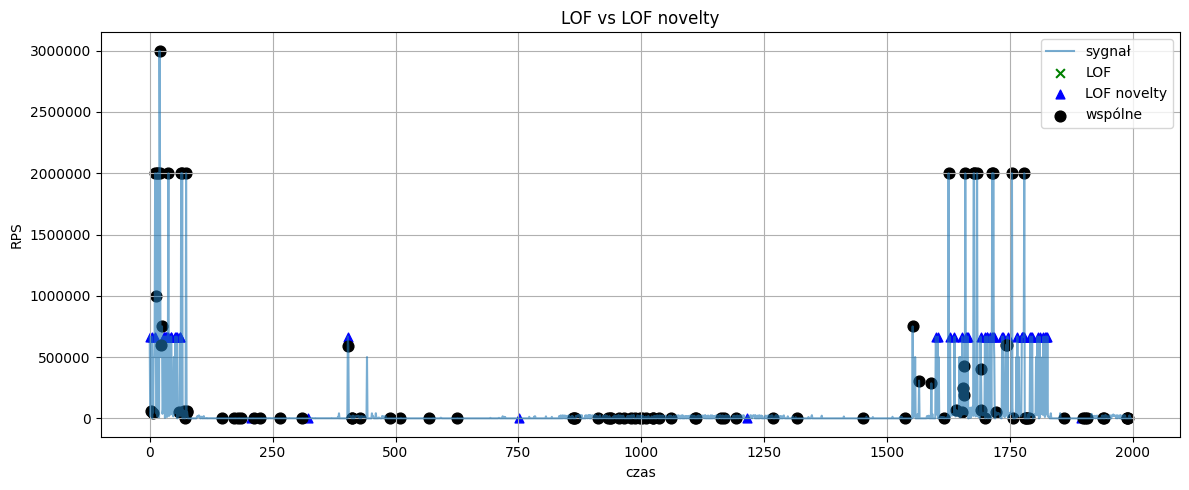

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(rps.values, label="sygnał", alpha=0.6)

plt.scatter(list(only_lof), rps.iloc[list(only_lof)],
            color='green', s=40, marker='x', label="LOF")

plt.scatter(list(only_novel), rps.iloc[list(only_novel)],
            color='blue', s=40, marker='^', label="LOF novelty")

plt.scatter(list(common), rps.iloc[list(common)],
            color='black', s=60, marker='o', label="wspólne")

plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')

plt.title("LOF vs LOF novelty")
plt.xlabel("czas")
plt.ylabel("RPS")

plt.legend()
plt.tight_layout()
plt.show()

Model LOF w trybie standardowym analizuje cały zbiór danych, przez co może traktować część anomalii jako normalne. Natomiast tryb novelty=True uczy się wyłącznie na danych normalnych i wykrywa odchylenia od tego wzorca. W efekcie model novelty wykazuje większą czułość na anomalie i bardziej agresywnie identyfikuje nietypowe zachowania.

# Część: Dane wielowymiarowe + metryki (precision, recall, F1)


# Przygotowanie cech

In [ ]:

df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df = df.head(30000)
print(df.shape)

(30000, 85)


In [5]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [ ]:
features = [
    ' Flow Duration', # Czas trwania przepływu
    ' Total Fwd Packets', # Całkowita liczba pakietów do przodu
    ' Total Backward Packets', # Całkowita liczba pakietów wstecz
    'Flow Bytes/s', # Bajty na sekundę
    ' Flow Packets/s', # Pakiety na sekundę
    ' Packet Length Mean', # Średnia długość pakietu
    ' Packet Length Std', # Odchylenie standardowe długości pakietu
    ' Average Packet Size', # Średni rozmiar pakietu
    'Idle Mean', # Średni czas bezczynności
    'Active Mean' # Średni czas aktywności
]

X = df[features]

In [7]:
y_true = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1).values

Zamienia wartości w kolumnie Label na liczby: BENIGN → 0 (normalny ruch), a pozostałe → 1 (atak), tworząc wektor dla modelu ML.

In [8]:
n_attack = (df[' Label'].str.strip() != 'BENIGN').sum()
n_normal = (df[' Label'].str.strip() == 'BENIGN').sum()

print("Ataki:", n_attack)
print("Normalne:", n_normal)

Ataki: 9889
Normalne: 20099


In [11]:
contamination = n_attack / (n_normal + n_attack)
print("Contamination:", contamination)

Contamination: 0.32976523942910496


# Dodanie standaryzacji cech

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score

def scores(name, y_true, y_pred):
    print(name)
    print("precision:", precision_score(y_true, y_pred))
    print("recall   :", recall_score(y_true, y_pred))
    print("f1       :", f1_score(y_true, y_pred))
    print()

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
# ze skalowaniem
iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_iso_scaled = (iso.fit_predict(X_scaled) == -1).astype(int)

# bez skalowania
iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_iso_no_scaled = (iso.fit_predict(X) == -1).astype(int)

# LOF
# ze skalowaniem
lof = LocalOutlierFactor(contamination=contamination)
y_pred_lof_scaled = (lof.fit_predict(X_scaled) == -1).astype(int)

# bez skalowania
lof = LocalOutlierFactor(contamination=contamination)
y_pred_lof_no_scaled = (lof.fit_predict(X) == -1).astype(int)

scores("Isolation Forest (scaled)", y_true, y_pred_iso_scaled)
scores("Isolation Forest (no scaling)", y_true, y_pred_iso_no_scaled)

scores("LOF (scaled)", y_true, y_pred_lof_scaled)
scores("LOF (no scaling)", y_true, y_pred_lof_no_scaled)

Isolation Forest (scaled)
precision: 0.5232076044089392
recall   : 0.5232076044089392
f1       : 0.5232076044089392

Isolation Forest (no scaling)
precision: 0.5178481140661341
recall   : 0.5178481140661341
f1       : 0.5178481140661341

LOF (scaled)
precision: 0.3110526848012944
recall   : 0.3110526848012944
f1       : 0.3110526848012944

LOF (no scaling)
precision: 0.3147942157953281
recall   : 0.3147942157953281
f1       : 0.3147942157953281



Skalowanie cech miało niewielki, ale zauważalny wpływ na wyniki modeli.
W przypadku Isolation Forest standaryzacja nieznacznie poprawiła wartość F1, co oznacza lepszą detekcję anomalii przy ujednoliceniu skali cech.Bez skalowania cechy o większych wartościach mogą dominować, co może pogarszać działanie modelu.

W modelu LOF zastosowanie skalowania spowodowało jednak niewielkie obniżenie wyników, co może wynikać z jego dużej wrażliwości na lokalną strukturę danych i zmiany odległości między punktami.
Ogólnie skalowanie poprawia stabilność modeli, choć jego wpływ zależy od zastosowanego algorytmu.

# Rozkładami cech ataku

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_base = (iso.fit_predict(X_scaled) == -1).astype(int)

scores("BASELINE", y_true, y_pred_base)

# WERSJA 1 — WYRAŹNY ATAK
df_high = df.copy()
attack_mask = df_high[' Label'].str.strip() != 'BENIGN'

df_high.loc[attack_mask, 'Flow Bytes/s'] *= 2
df_high.loc[attack_mask, ' Flow Packets/s'] *= 2
X_high = df_high[X.columns]
X_high_scaled = scaler.fit_transform(X_high)

iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_high = (iso.fit_predict(X_high_scaled) == -1).astype(int)

scores("ATAK BARDZIEJ WYRAŹNY", y_true, y_pred_high)

# WERSJA 2 — ATAK PODOBNY
df_low = df.copy()
attack_mask = df_low[' Label'].str.strip() != 'BENIGN'

df_low.loc[attack_mask, 'Flow Bytes/s'] *= 0.5
df_low.loc[attack_mask, ' Flow Packets/s'] *= 0.7

X_low = df_low[X.columns]
X_low_scaled = scaler.fit_transform(X_low)

iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_low = (iso.fit_predict(X_low_scaled) == -1).astype(int)

scores("ATAK PODOBNY DO NORMALNEGO", y_true, y_pred_low)

BASELINE
precision: 0.5232076044089392
recall   : 0.5232076044089392
f1       : 0.5232076044089392

ATAK BARDZIEJ WYRAŹNY
precision: 0.5209829103043786
recall   : 0.5209829103043786
f1       : 0.5209829103043786

ATAK PODOBNY DO NORMALNEGO
precision: 0.5166346445545555
recall   : 0.5166346445545555
f1       : 0.5166346445545555



Zmiana rozkładu cech ataku miała niewielki wpływ na wartość F1, a w niektórych przypadkach doprowadziła do jej spadku. Wynika to z faktu, że parametr contamination został ustawiony zgodnie z rzeczywistym udziałem anomalii, przez co model zawsze oznacza podobną liczbę obserwacji jako anomalne. Ponadto Isolation Forest opiera się na globalnej strukturze danych, dlatego zmiana tylko wybranych cech może zmieniać ranking punktów, co nie zawsze prowadzi do poprawy detekcji. Pokazuje to ograniczenie podejścia oraz złożoność wpływu rozkładu cech na skuteczność modelu.

# Silniejsza nierównowaga klas

In [92]:

df.columns = df.columns.str.strip()
df_attack = df[df['Label'] != 'BENIGN']
df_normal = df[df['Label'] == 'BENIGN']


# tworzenie nierównosci
df_imb = pd.concat([
    df_normal.sample(15000, random_state=0),
    df_attack.sample(200, random_state=0)
])

print("Rozkład klas:")
print(df_imb['Label'].value_counts())

X_imb = df_imb[features]
y_imb = (df_imb['Label'] != 'BENIGN').astype(int).values

# contamination
n_attack = (y_imb == 1).sum()
n_normal = (y_imb == 0).sum()

contamination_imb = n_attack / (n_attack + n_normal)
print("Contamination:", contamination_imb)


scaler = StandardScaler()
X_imb_scaled = scaler.fit_transform(X_imb)
iso = IsolationForest(contamination=contamination_imb, random_state=0)
y_pred_imb = (iso.fit_predict(X_imb_scaled) == -1).astype(int)

scores("SILNA NIERÓWNOWAGA", y_imb, y_pred_imb)

Rozkład klas:
Label
BENIGN    15000
DDoS        200
Name: count, dtype: int64
Contamination: 0.013157894736842105
SILNA NIERÓWNOWAGA
precision: 0.28
recall   : 0.28
f1       : 0.28



W przypadku silnej nierównowagi klas skuteczność modelu uległa znacznemu pogorszeniu. Wartość F1 spadła z około 0.52 do 0.28, co oznacza, że model ma trudności z wykrywaniem rzadkich anomalii. Przy bardzo małym udziale ataków (ok. 1.3%) model oznacza niewielką liczbę obserwacji jako anomalne, co prowadzi do spadku recall. Pokazuje to, że detekcja anomalii jest szczególnie wymagająca w przypadku silnie niezrównoważonych danych.

# Porównanie kilku modeli + NOWY MODEL

In [95]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

# Isolation Forest
iso = IsolationForest(contamination=contamination, random_state=0)
y_pred_iso = (iso.fit_predict(X_scaled) == -1).astype(int)

# LOF
lof = LocalOutlierFactor(contamination=contamination, n_neighbors=50)
y_pred_lof = (lof.fit_predict(X_scaled) == -1).astype(int)

# One-Class SVM
svm = OneClassSVM(gamma='scale', nu=contamination)
y_pred_svm = (svm.fit_predict(X_scaled) == -1).astype(int)

# Elliptic Envelope (NOWY MODEL)
ell = EllipticEnvelope(contamination=contamination, random_state=0)
y_pred_ell = (ell.fit_predict(X_scaled) == -1).astype(int)

# zestawienie wyników
results = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "LOF",
        "OneClassSVM",
        "Elliptic Envelope"
    ],
    "Precision": [
        precision_score(y_true, y_pred_iso),
        precision_score(y_true, y_pred_lof),
        precision_score(y_true, y_pred_svm),
        precision_score(y_true, y_pred_ell)
    ],
    "Recall": [
        recall_score(y_true, y_pred_iso),
        recall_score(y_true, y_pred_lof),
        recall_score(y_true, y_pred_svm),
        recall_score(y_true, y_pred_ell)
    ],
    "F1": [
        f1_score(y_true, y_pred_iso),
        f1_score(y_true, y_pred_lof),
        f1_score(y_true, y_pred_svm),
        f1_score(y_true, y_pred_ell)
    ]
})

print(results)

C:\Users\fi115\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


               Model  Precision    Recall        F1
0   Isolation Forest   0.521590  0.521590  0.521590
1                LOF   0.310749  0.310749  0.310749
2        OneClassSVM   0.422836  0.422793  0.422814
3  Elliptic Envelope   0.704590  0.693902  0.699205


Elliptic Envelope to model statystyczny, który zakłada, że większość danych ma rozkaład normalny. Tworzy on coś w rodzaju obszaru (elipsy), w którym znajdują się typowe dane. Jeśli jakiś punkt znajduje się poza tym obszarem, jest uznawany za anomalię. Model działa najlepiej, gdy dane są uporządkowane i mają regularny rozkład.

Model Elliptic Envelope osiągnął najlepszy wynik spośród wszystkich modeli (F1 ≈ 0.70, precision ≈ 0.70, recall ≈ 0.69), co oznacza, że najskuteczniej wykrywał anomalie. Isolation Forest uzyskał wynik na poziomie F1 ≈ 0.52, co wskazuje na dobrą, ale niższą skuteczność. One-Class SVM osiągnął średni wynik (F1 ≈ 0.42), natomiast LOF był najsłabszy (F1 ≈ 0.31). Wyniki pokazują, że w tym przypadku model statystyczny (Elliptic Envelope) najlepiej dopasował się do danych i najdokładniej oddzielił anomalie od normalnych obserwacji.

# Część: Logi Nginx / Wireshark – parsowanie i budowa cech

NOWE DANE Apache.log


# Agregacja po minutach zamiast po sekundach

In [1]:
from datetime import datetime

def parse_time_second(s):
    return datetime.strptime(s, "%a %b %d %H:%M:%S %Y")

def parse_time_minute(s):
    dt = datetime.strptime(s, "%a %b %d %H:%M:%S %Y")
    return dt.replace(second=0)

In [2]:
import re
from collections import defaultdict

pattern = re.compile(
    r'\[(?P<time>.*?)\] \[(?P<level>\w+)\](?: \[client (?P<ip>[\d\.]+)\])? (?P<msg>.*)'
)

def count_buckets(logs, parse_func):
    buckets = defaultdict(list)

    for line in logs:
        m = pattern.search(line)
        if not m:
            continue
        t = parse_func(m.group("time"))
        buckets[t].append(line)

    return buckets

with open("Apache.log") as f:
    logs = f.readlines()

b_sec = count_buckets(logs, parse_time_second)
b_min = count_buckets(logs, parse_time_minute)

print("Sekundy:", len(b_sec))
print("Minuty :", len(b_min))

Sekundy: 16445
Minuty : 8258


Liczba bucketów czasowych zmniejszyła się z 16445 do 8258 po zastosowaniu agregacji minutowej. Oznacza to, że wiele obserwacji z poziomu sekundowego zostało połączonych w większe okna czasowe, co prowadzi do redukcji liczby analizowanych punktów danych

In [3]:
import numpy as np
from collections import Counter

def compute_features(buckets):
    features = []

    for rec in buckets.values():
        ips = [pattern.search(l).group("ip") for l in rec if pattern.search(l).group("ip")]
        levels = [pattern.search(l).group("level") for l in rec]

        rps = len(rec)
        unique_ips = len(set(ips))
        error_rate = np.mean([1 if l == "error" else 0 for l in levels])
        max_ip = max(Counter(ips).values()) if ips else 0

        features.append([rps, unique_ips, error_rate, max_ip])

    return np.array(features)

X_sec = compute_features(b_sec)
X_min = compute_features(b_min)

print("Śr RPS sek:", np.mean(X_sec[:,0]))
print("Śr RPS min:", np.mean(X_min[:,0]))

Śr RPS sek: 3.1622985709942233
Śr RPS min: 6.29740857350448


Średnia liczba żądań (RPS) wzrosła z 3.16 do 6.30 po agregacji minutowej. Wynika to z faktu, że w większych oknach czasowych kumulowane są zdarzenia z wielu sekund, co prowadzi do wzrostu wartości tej cechy.

# Dodanie nowych cech z logów

In [4]:
from collections import Counter

def extra_features(rec):
    ips = [r["ip"] for r in rec if r["ip"]]
    msgs = [r["msg"] for r in rec]

    # 1. liczba różnych komunikatów
    unique_msgs = len(set(msgs))

    # 2. koncentracja IP, jak bardzo dominujace jest jedno ip
    if len(ips) == 0:
        ip_concentration = 0
    else:
        ip_counts = Counter(ips)
        max_requests = max(ip_counts.values())
        ip_concentration = max_requests / len(ips)

    return unique_msgs, ip_concentration

In [5]:
def parse_apache_log(file_path):
    records = []

    with open(file_path, "r") as f:
        for line in f:
            parts = line.split()

            if len(parts) > 6:
                ip = parts[0]

                # request jest między cudzysłowami
                msg = " ".join(parts[5:8]).replace('"', '')

                records.append({
                    "ip": ip,
                    "msg": msg
                })

    return records
records = parse_apache_log("Apache.log")
# dodatkowe cechy
unique_msgs, ip_concentration = extra_features(records)
print("Unique messages:", unique_msgs)
print("IP concentration:", ip_concentration)

Unique messages: 4714
IP concentration: 0.1774193548387097


Wprowadzono dodatkowe cechy: unique_msgs, opisującą liczbę różnych komunikatów logów w danym oknie czasowym, oraz ip_concentration, określającą udział ruchu generowanego przez najbardziej aktywny adres IP.

Pierwsza cecha pozwala wykrywać różnorodność zapytań charakterystyczną dla skanowania systemu, natomiast druga umożliwia identyfikację ataków typu flood, w których jeden adres IP generuje znaczną część ruchu.

# Oznaczanie „podejrzanych” IP

In [6]:
from collections import Counter

def ip_features(rec):
    ips = [r["ip"] for r in rec if r["ip"]]
    ip_counts = Counter(ips)

    max_requests_ip = max(ip_counts.values()) if ip_counts else 0 #max liczba żądań z jednego IP w danym oknie,
    suspicious_ips = sum(1 for ip, c in ip_counts.items() if c > 10) #liczba IP, które przekroczyły np. 10 żądań w oknie.

    return max_requests_ip, suspicious_ips

In [7]:
records = parse_apache_log("apache.log")

max_req, suspicious = ip_features(records)

print("max liczba żądań z jednego IP w danym oknie:", max_req)
print("Liczba podejrzanych IP (>10 żądań):", suspicious)

max liczba żądań z jednego IP w danym oknie: 10021
Liczba podejrzanych IP (>10 żądań): 8


# Automatyczny pipeline: logi → cechy → model

In [8]:
from collections import defaultdict, Counter
from sklearn.ensemble import IsolationForest

pattern = re.compile( # regex na parsowanie logów Apache    
    r'\[(?P<time>.*?)\] \[(?P<level>\w+)\](?: \[client (?P<ip>[\d\.]+)\])? (?P<msg>.*)'
)

def parse_time_minute(s): # parsowanie czasu z dokładnością do minuty
    dt = datetime.strptime(s, "%a %b %d %H:%M:%S %Y")
    return dt.replace(second=0)

def build_features_from_logs(log_lines):
    buckets = defaultdict(list)

    for line in log_lines:
        m = pattern.search(line)
        if not m:
            continue

        t = parse_time_minute(m.group("time"))

        buckets[t].append({ # parsowanie do słownika
            "ip": m.group("ip"),
            "level": m.group("level")
        })

    features = []

    for rec in buckets.values():
        rps = len(rec) # liczba żądań w oknie

        ips = [r["ip"] for r in rec if r["ip"]] # lista IP w oknie
        unique_ips = len(set(ips)) # liczba unikalnych IP w oknie

        error_rate = np.mean([1 if r["level"] == "error" else 0 for r in rec]) # odsetek błędów w oknie

        ip_counts = Counter(ips) # zliczanie żądań z każdego IP
        max_ip = max(ip_counts.values()) if ip_counts else 0 # maksymalna liczba żądań z jednego IP w oknie
        suspicious_ips = sum(1 for ip, c in ip_counts.items() if c > 10) # liczba IP, które przekroczyły np. 10 żądań w oknie

        features.append([rps, unique_ips, error_rate, max_ip, suspicious_ips])

    return np.array(features)


# użycie
with open("Apache.log") as f:
    logs = f.readlines()

X = build_features_from_logs(logs)

iso = IsolationForest(contamination=0.05, random_state=0)
labels_iso = iso.fit_predict(X)

print("Anomalie:", (labels_iso == -1).sum())

Anomalie: 411


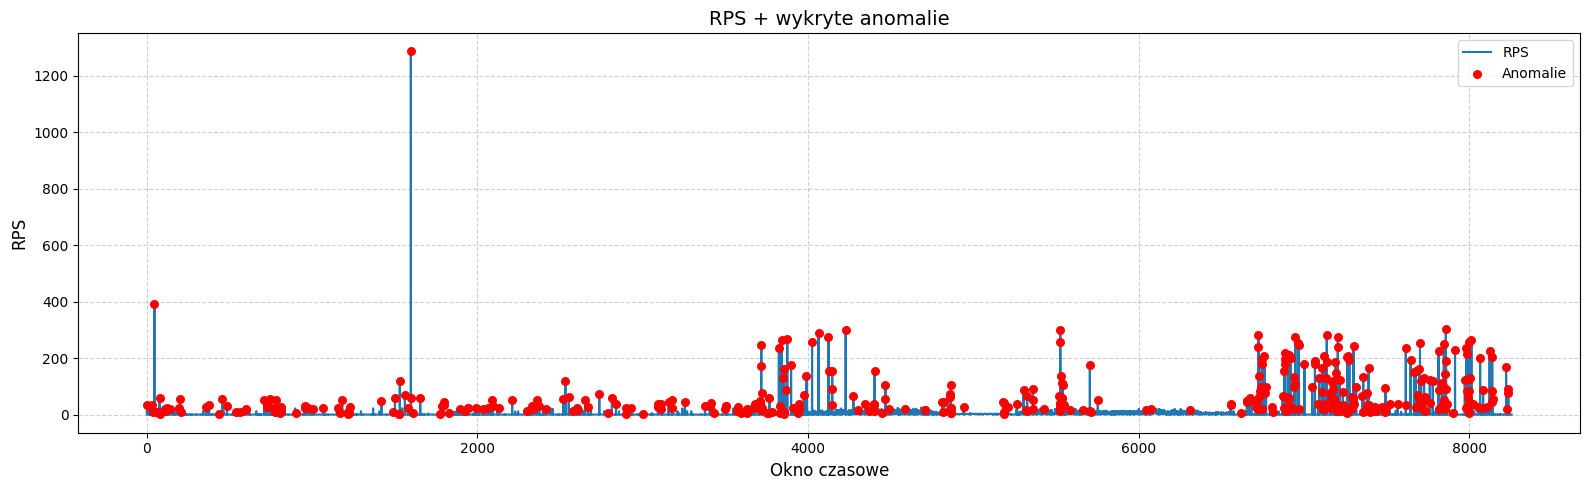

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5)) 
plt.plot(X[:,0], label="RPS", linewidth=1.5)

# anomalie
anomaly_idx = np.where(labels_iso == -1)[0]
plt.scatter(
    anomaly_idx,
    X[anomaly_idx, 0],
    color='red',          
    label='Anomalie',
    s=30,                
    zorder=3             
)

plt.title("RPS + wykryte anomalie", fontsize=14)
plt.xlabel("Okno czasowe", fontsize=12)
plt.ylabel("RPS", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.legend()
plt.tight_layout()  
plt.show()

Na podstawie zbudowanego pipeline’u przekształcono logi Apache do postaci cech opisujących ruch sieciowy w oknach czasowych. Następnie zastosowano model Isolation Forest do wykrywania anomalii.

Na wykresie przedstawiono przebieg liczby żądań (RPS) w czasie, wraz z zaznaczonymi punktami uznanymi przez model za anomalne. W analizowanym zbiorze wykryto 411 anomalii.

Anomalie odpowiadają głównie nagłym wzrostom liczby żądań (RPS), które mogą wskazywać na nietypową aktywność, taką jak skanowanie zasobów, błędne zapytania lub próby ataku. Szczególnie widoczny jest pojedynczy bardzo wysoki pik (ponad 1200 żądań), który stanowi wyraźne odstępstwo od typowego ruchu i najprawdopodobniej odpowiada intensywnemu zdarzeniu. Dodatkowo obserwowane są grupy podwyższonej aktywności (np. w zakresie 200–300 żądań), które również zostały częściowo zaklasyfikowane jako anomalne.

Wyniki wskazują, że model skutecznie identyfikuje zarówno pojedyncze ekstremalne zdarzenia, jak i bardziej subtelne wzorce odbiegające od normalnego ruchu.

# Dodanie „szumu” do logów

In [ ]:
# PRZED
X_clean = build_features_from_logs(logs)

rps_clean = np.mean(X_clean[:,0])
ip_clean = np.mean(X_clean[:,1])
err_clean = np.mean(X_clean[:,2])

# Dodanie szumu 
fake_logs = logs.copy()

# Typ 1: 200 IP x 20 żądań (notice)
# dodane 200 IP, które generują dużo żądań (notice) - np. boty skanujące stronę
for ip_num in range(200):
    ip = f"10.{ip_num // 256}.{ip_num % 256}.{ip_num}"
    for j in range(20):
        fake_logs.append(
            "[Thu Jun 09 22:00:{:02d} 2005] [notice] [client {}] GET /page.html".format(j % 60, ip)
        )

# Typ 2: 10 IP x 15 błędów (error)
# dodane 10 IP, które generują dużo błędów (error) - np. atakujący próbujący różne payloady
for ip_num in range(10):
    ip = f"192.168.1.{100 + ip_num}"
    for j in range(15):
        fake_logs.append(
            "[Thu Jun 09 22:01:{:02d} 2005] [error] [client {}] 404 Not Found".format(j % 60, ip)
        )


X_noise = build_features_from_logs(fake_logs)
rps_noise = np.mean(X_noise[:,0])
ip_noise = np.mean(X_noise[:,1])
err_noise = np.mean(X_noise[:,2])

# Porównanie
print("=== PORÓWNANIE ===")
print("RPS:", rps_clean, "→", rps_noise, f"(wzrost: {(rps_noise/rps_clean - 1)*100:.1f}%)")
print("Unique IP:", ip_clean, "→", ip_noise, f"(wzrost: {(ip_noise/ip_clean - 1)*100:.1f}%)")
print("Error rate:", err_clean, "→", err_noise, f"(wzrost: {(err_noise/err_clean - 1)*100:.1f}%)")
print("Max IP:", np.max(X_clean[:,3]), "→", np.max(X_noise[:,3]))
print("Suspicious IPs:", np.max(X_clean[:,4]), "→", np.max(X_noise[:,4]))

=== PORÓWNANIE ===
RPS: 6.29740857350448 → 6.7983050847457624 (wzrost: 8.0%)
Unique IP: 0.7677403729716639 → 0.7929782082324455 (wzrost: 3.3%)
Error rate: 0.788342962528603 → 0.7882731458306542 (wzrost: -0.0%)
Max IP: 1002.0 → 1002.0
Suspicious IPs: 4.0 → 200.0


W celu analizy wpływu dodatkowego ruchu na cechy systemu rozszerzyłem logi o sztuczny szum. Dodałem dwa typy ruchu: dużą liczbę poprawnych żądań (notice) z wielu różnych adresów IP oraz błędne zapytania (error) generowane przez ograniczoną liczbę IP.

Następnie ponownie obliczyłem cechy i porównałem je z wartościami uzyskanymi dla oryginalnych danych. Zaobserwowałem wzrost liczby żądań (RPS) o około 8% oraz niewielki wzrost liczby unikalnych adresów IP o około 3.3%. Wartość error_rate pozostała praktycznie bez zmian, co wynika z dominacji błędów już w oryginalnym zbiorze danych.

Największą zmianę zauważyłem w liczbie podejrzanych adresów IP (suspicious_ips), która wzrosła z 4 do 200, co wynika z dodania wielu aktywnych adresów generujących powtarzalne żądania. Natomiast maksymalna liczba żądań z jednego IP (max_ip) nie uległa zmianie, ponieważ w danych początkowych występowały już bardzo intensywne źródła ruchu.

Uzyskane wyniki pokazują, że dodany szum wpływa głównie na rozproszenie ruchu oraz liczbę aktywnych adresów IP, natomiast nie zmienia istotnie najbardziej ekstremalnych obserwacji.

# DODATKOWE 

In [8]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# tylko pierwszych wierszy
df = df.head(30000)
print(df.shape)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
features = [
    ' Flow Duration',
    ' Total Fwd Packets',
    ' Total Backward Packets',
    'Flow Bytes/s',
    ' Flow Packets/s',
    ' Packet Length Mean',
    ' Packet Length Std',
    ' Average Packet Size',
    'Idle Mean',
    'Active Mean'
]
y_true = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1).values

X = df[features]

(30000, 85)


In [9]:
n_attack = (df[' Label'].str.strip() != 'BENIGN').sum()
n_normal = (df[' Label'].str.strip() == 'BENIGN').sum()

print("Ataki:", n_attack)
print("Normalne:", n_normal)

Ataki: 9889
Normalne: 20099


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score

# Trening tylko na normalnych
X_normal = X_scaled[y_true == 0]

X_train_tensor = torch.tensor(X_normal, dtype=torch.float32)
X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# MODEL
class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# TRENING
model = ImprovedAutoencoder(input_dim=X_scaled.shape[1])

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 200
batch_size = 64

for epoch in range(epochs):
    perm = torch.randperm(X_train_tensor.size(0))

    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_idx = perm[i:i+batch_size]
        batch = X_train_tensor[batch_idx]

        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


# REKONSTRUKCJA
model.eval()
with torch.no_grad():
    reconstructions = model(X_all_tensor).numpy()

mse_values = np.mean((X_scaled - reconstructions) ** 2, axis=1)


mse_normal = mse_values[y_true == 0]
threshold = np.percentile(mse_normal, 95)
print(f"Threshold: {threshold:.6f}")
y_pred = (mse_values > threshold).astype(int)

# METRYKI
nn_precision = precision_score(y_true, y_pred)
nn_recall = recall_score(y_true, y_pred)
nn_f1 = f1_score(y_true, y_pred)
print(f"Precision: {nn_precision:.6f}")
print(f"Recall: {nn_recall:.6f}")
print(f"F1: {nn_f1:.6f}")



Epoch 0, Loss: 0.379805
Epoch 20, Loss: 0.459691
Epoch 20, Loss: 0.459691
Epoch 40, Loss: 0.454060
Epoch 40, Loss: 0.454060
Epoch 60, Loss: 1.174119
Epoch 60, Loss: 1.174119
Epoch 80, Loss: 1.102803
Epoch 80, Loss: 1.102803
Epoch 100, Loss: 0.580701
Epoch 100, Loss: 0.580701
Epoch 120, Loss: 1.043422
Epoch 120, Loss: 1.043422
Epoch 140, Loss: 0.524503
Epoch 140, Loss: 0.524503
Epoch 160, Loss: 0.332972
Epoch 160, Loss: 0.332972
Epoch 180, Loss: 0.904695
Epoch 180, Loss: 0.904695
Threshold: 0.312325
Precision: 0.836132
Recall: 0.518556
F1: 0.640120
Threshold: 0.312325
Precision: 0.836132
Recall: 0.518556
F1: 0.640120


In [29]:

data = {
    "Model": [
        "Isolation Forest",
        "LOF",
        "One-Class SVM",
        "Elliptic Envelope",
        "Neural Network Autoencoder"
    ],
    "Precision": [
        0.521590,
        0.310749,
        0.422836,
        0.704590,
        nn_precision
    ],
    "Recall": [
        0.521590,
        0.310749,
        0.422793,
        0.693902,
        nn_recall
    ],
    "F1": [
        0.521590,
        0.310749,
        0.422814,
        0.699205,
        nn_f1
    ]
}

df_results = pd.DataFrame(data)

print(df_results)

                        Model  Precision    Recall        F1
0            Isolation Forest   0.521590  0.521590  0.521590
1                         LOF   0.310749  0.310749  0.310749
2               One-Class SVM   0.422836  0.422793  0.422814
3           Elliptic Envelope   0.704590  0.693902  0.699205
4  Neural Network Autoencoder   0.836132  0.518556  0.640120


Opis modelu (Autoencoder)

Zastosowałem model typu autoencoder zaimplementowany w PyTorch. Skupiłem się na części kodującej (encoder), której zadaniem jest kompresja danych wejściowych do niższej reprezentacji (tzw. bottleneck). Encoder składa się z kilku warstw liniowych (Linear), pomiędzy którymi zastosowałem funkcję aktywacji ReLU, normalizację BatchNorm oraz warstwy Dropout w celu ograniczenia przeuczenia. Architektura stopniowo zmniejsza wymiar danych (np. 128 → 64 → 32 → 16), co pozwala modelowi nauczyć się najważniejszych cech opisujących dane normalne. Dzięki temu encoder tworzy zwartą reprezentację danych, która jest później wykorzystywana do ich rekonstrukcji, a wysoki błąd rekonstrukcji wskazuje na potencjalną anomalię.

Wyniki

Na podstawie uzyskanych wyników zauważyłem, że najlepszą równowagę pomiędzy precyzją a czułością osiągnął model Elliptic Envelope (Precision ≈ 0.70, Recall ≈ 0.69, F1 ≈ 0.70), co wskazuje na dobre dopasowanie danych do jego założeń. Isolation Forest uzyskał umiarkowane wyniki (F1 ≈ 0.52), natomiast LOF i One-Class SVM wypadły słabiej, osiągając niższe wartości wszystkich metryk.
Zastosowany przeze mnie autoencoder osiągnął najwyższą precyzję (≈ 0.84) spośród wszystkich modeli, co oznacza, że wykrywane anomalie są w dużej mierze poprawne. Jednocześnie uzyskał recall na poziomie ≈ 0.52, co wskazuje na umiarkowaną zdolność wykrywania wszystkich anomalii. W rezultacie wartość F1 ≈ 0.64 pokazuje, że model stanowi dobre kompromisowe rozwiązanie, skutecznie ogranicza fałszywe alarmy, a jednocześnie zachowując przyzwoitą wykrywalność anomalii.